In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dev_path = "data/raw/casas_dev.csv"
test_path = "data/raw/casas_test.csv"

casas_dev_df = pd.read_csv(dev_path)
casas_test_df = pd.read_csv(test_path)

In [3]:
print('shape = ', casas_dev_df.shape)
casas_dev_df.sample(5)

shape =  (900, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
733,120.0,m2,0,0,5.0,218.0,-34.576339,-58.363130,4.0
600,1249.0,sqft,0,0,10.0,854.0,40.696922,-74.043946,4.0
510,47.0,m2,1,0,NaN,108.0,-34.610969,-58.365064,1.0
447,92.0,m2,1,0,7.0,175.0,-34.596283,-58.346747,3.0
550,1033.0,sqft,0,1,9.0,1275.0,40.713119,-74.005532,3.0


In [4]:
print('shape = ', casas_test_df.shape)
casas_test_df.sample(5)

shape =  (100, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
14,1033.0,sqft,0,0,11.0,716.0,40.695764,-74.013572,3.0
34,50.0,m2,1,0,7.0,93.0,-34.591901,-58.323440,2.0
63,79.0,m2,0,0,NaN,124.0,-34.632125,-58.444064,2.0
64,1109.0,sqft,0,0,1.0,829.0,40.764016,-74.006268,3.0
51,753.0,sqft,0,0,1.0,571.0,40.686219,-73.972013,2.0


# 1) Exploración de datos

El orden de los incisos correspondientes al ejercicio 1 fueron alterados por cuestiones de eficacia y buenas prácticas.

#### 1.1 primera parte) -> analizamos los valores faltantes en los datasets.

In [5]:
from src.utils import missing_percentages, missing_values

In [6]:
print("Dev Set")
missing_values(casas_dev_df)
missing_percentages(casas_dev_df)


Dev Set

Valores faltantes por columna:
area            0
area_units      0
is_house        0
has_pool        0
age           130
price           0
lat             0
lon             0
rooms          72
dtype: int64
Valores NaN en 'age': 130 sobre un total de 900 filas (14.44%)
Valores NaN en 'rooms': 72 sobre un total de 900 filas (8.00%)


Dropear 14.44% y/o 8% de los datos por una feature faltante sería desperdiciar mucha información por lo que intentaremos estimar estos valores faltantes. Para eso, anaelicemos el resto de las features y sus correlaciones.

In [7]:
print("Test Set")
missing_values(casas_test_df)
missing_percentages(casas_test_df)

Test Set

Valores faltantes por columna:
area           0
area_units     0
is_house       0
has_pool       0
age           16
price          0
lat            0
lon            0
rooms          4
dtype: int64
Valores NaN en 'age': 16 sobre un total de 100 filas (16.00%)
Valores NaN en 'rooms': 4 sobre un total de 100 filas (4.00%)


##### Revisión de unidades

In [8]:
print(casas_dev_df['area_units'].value_counts())

area_units
m2      463
sqft    437
Name: count, dtype: int64


Conversión/unificación de unidades

In [9]:
print(casas_test_df['area_units'].value_counts())

area_units
m2      53
sqft    47
Name: count, dtype: int64


In [10]:
from src.preprocessing import area_units_conversion

In [11]:
units_converted_dev_df = area_units_conversion(casas_dev_df)

In [12]:
units_converted_test_df = area_units_conversion(casas_test_df)

In [13]:
units_converted_dev_df.sample(5)

,area,is_house,has_pool,age,price,lat,lon,rooms
279,112.970206,0,0,7.0,896.0,40.704304,-74.006561,3.0
422,77.000000,1,0,12.0,147.0,-34.630388,-58.401619,2.0
89,95.000000,0,0,5.0,196.0,-34.612849,-58.371160,3.0
68,115.014075,0,0,NaN,880.0,40.703954,-74.025170,4.0
760,82.000000,1,0,NaN,188.0,-34.594131,-58.376226,2.0


Ahora sí podemos visualizar las distribuciones de dev

(resolveremos los valores faltantes NaNs más adelante)

#### 1.2)

In [14]:
from src.plotting import plot_distributions, plot_scatter_matrix, plot_correlation

#### Dev Set

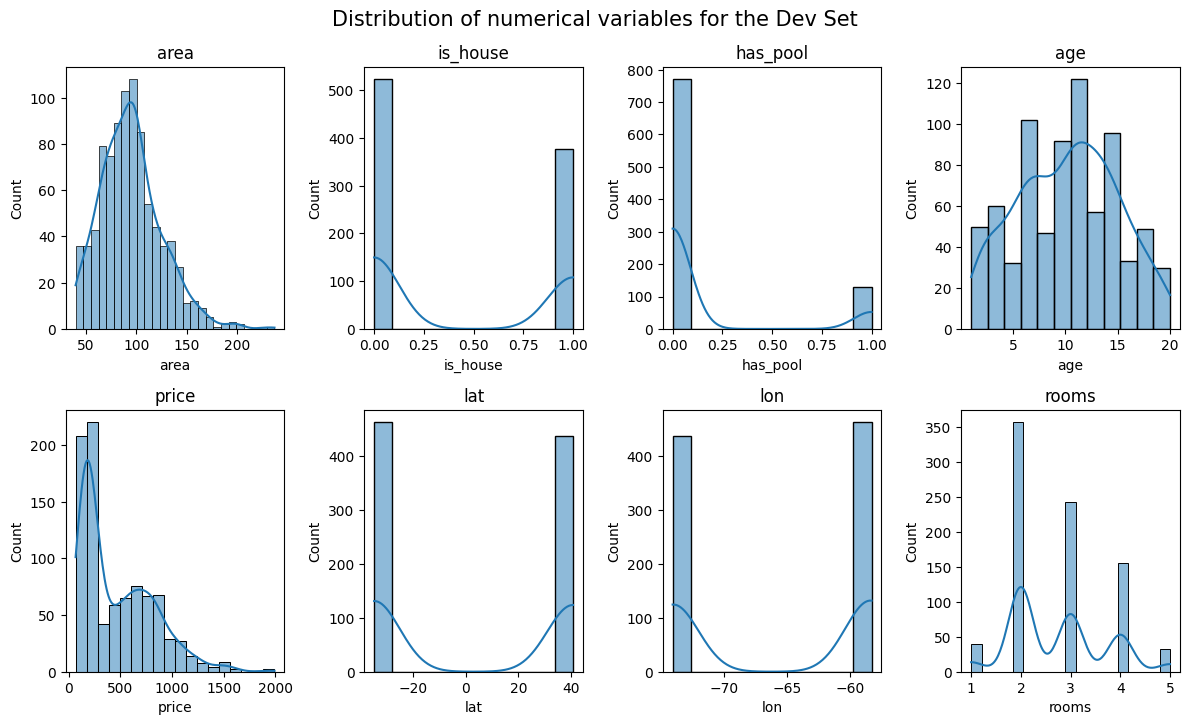

In [15]:
plot_distributions(units_converted_dev_df, "Dev")

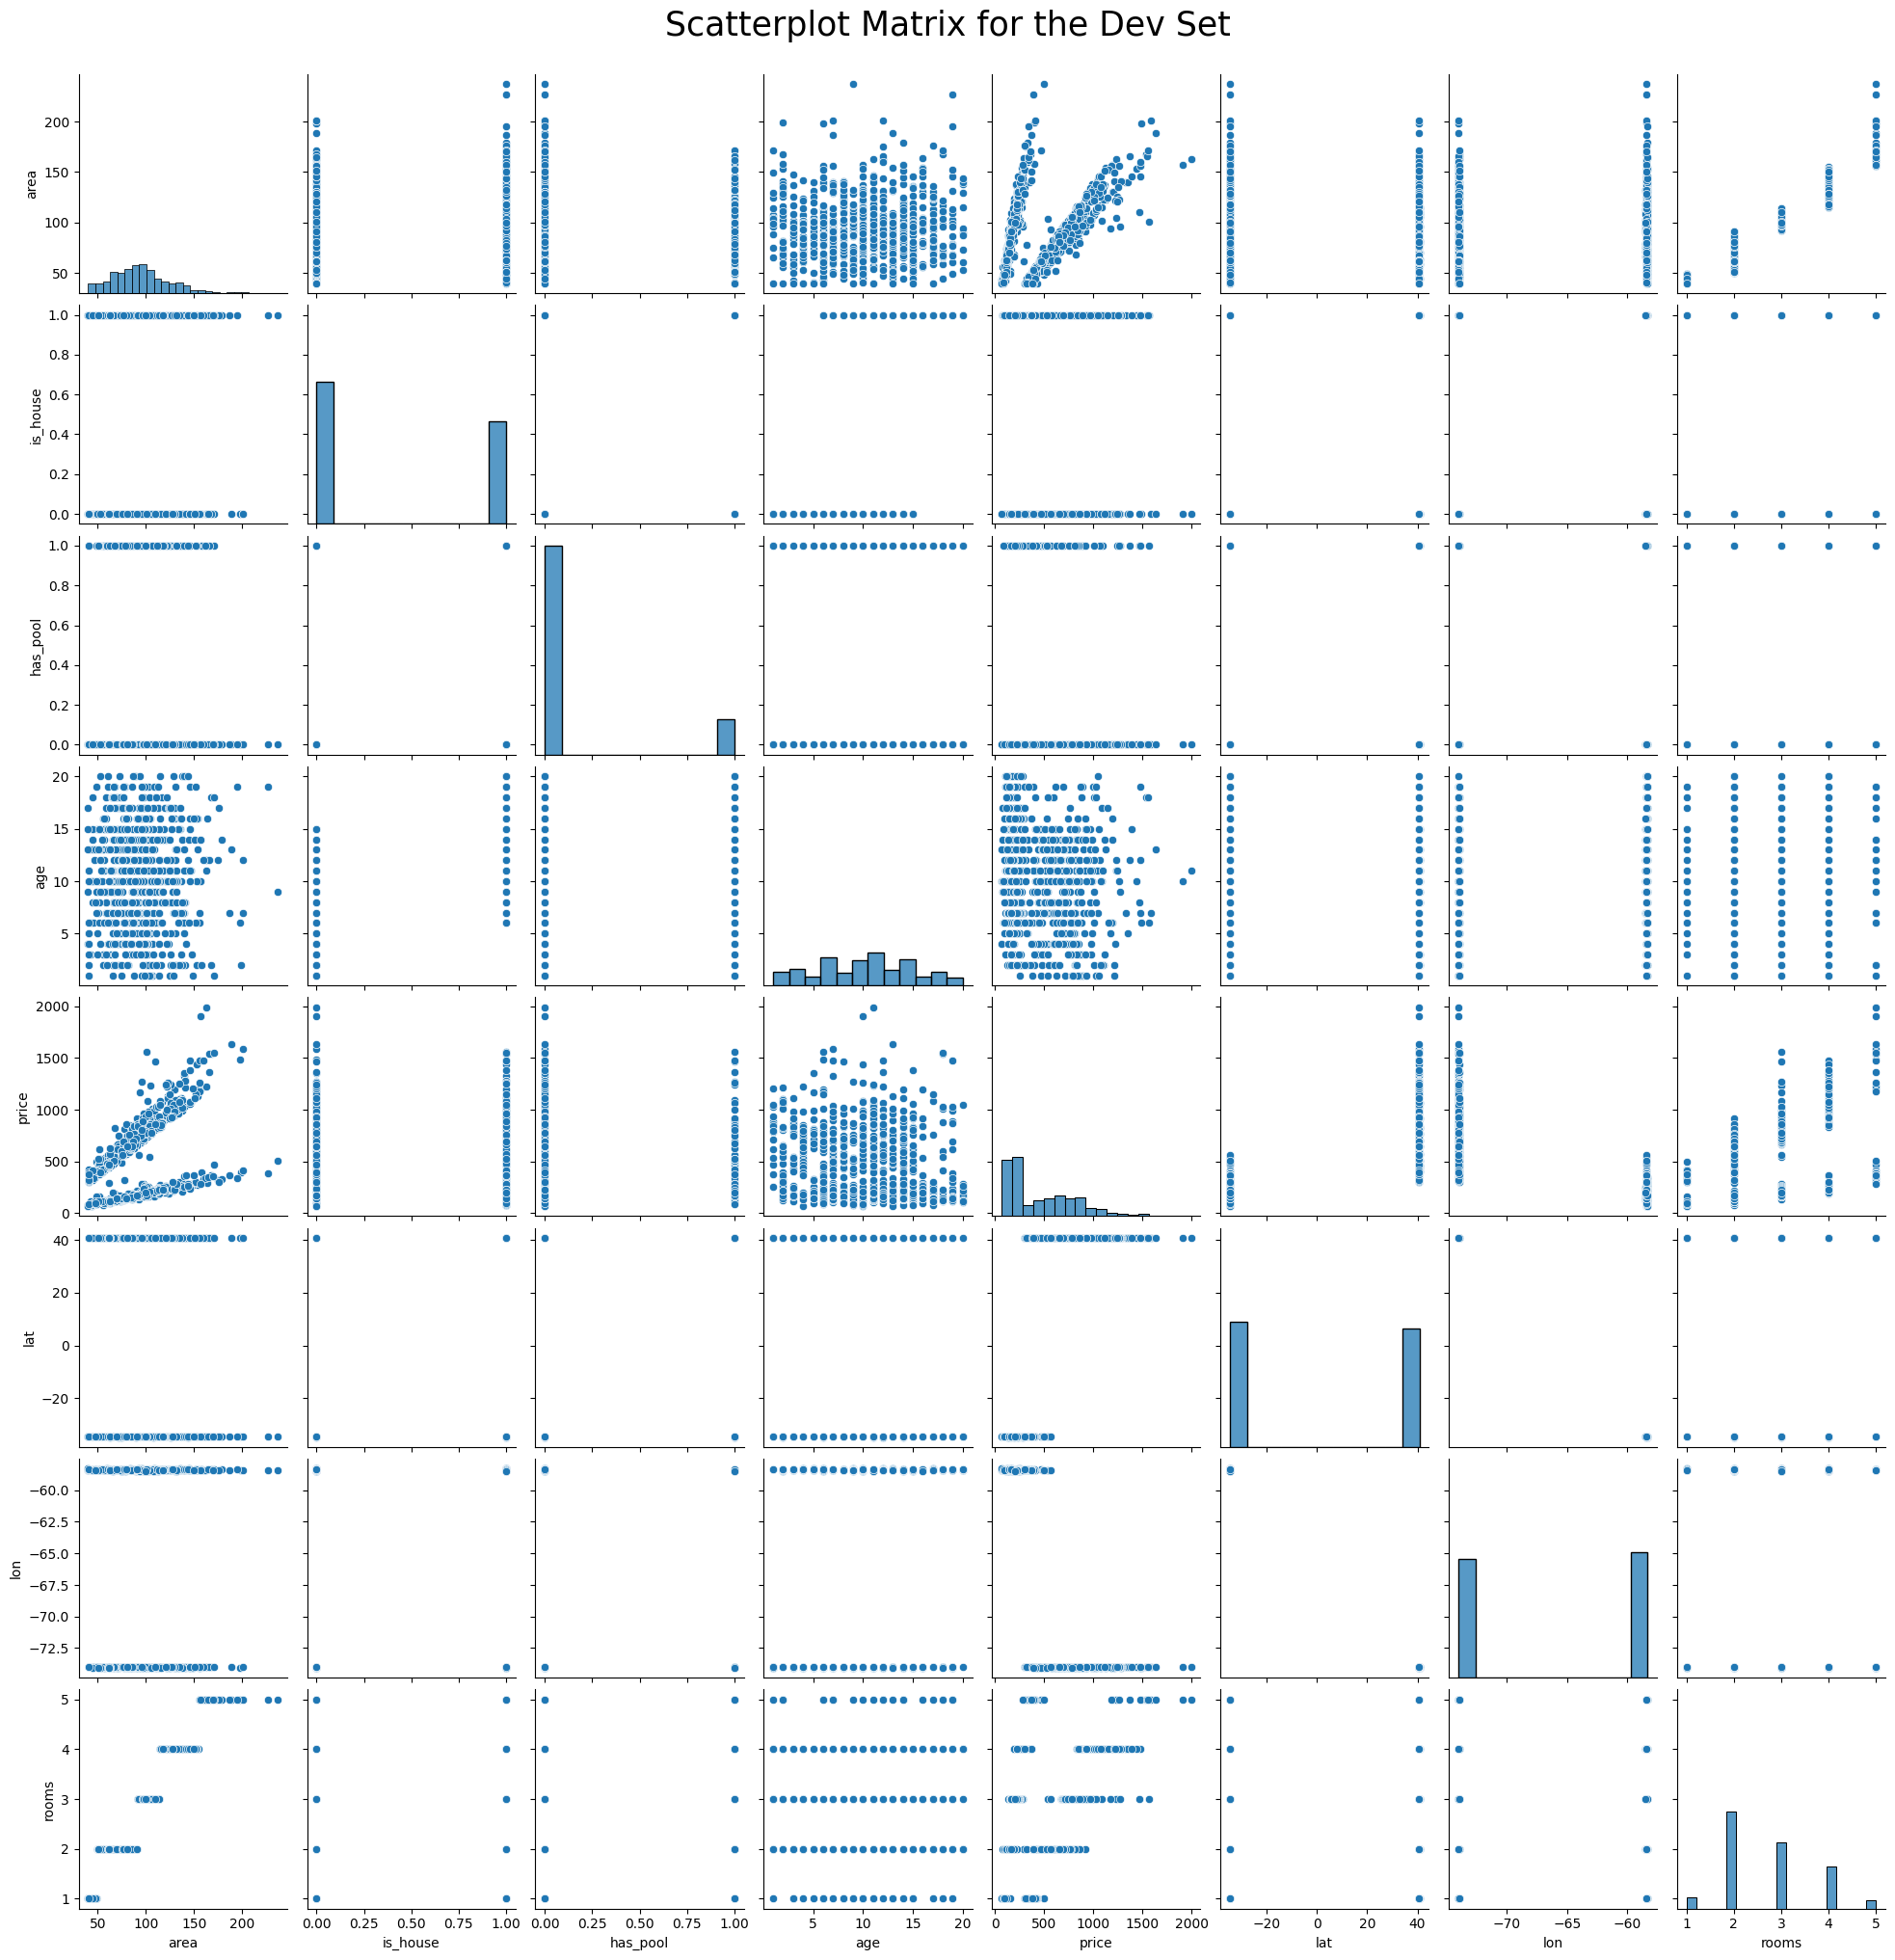

In [16]:
plot_scatter_matrix(units_converted_dev_df, "Dev")

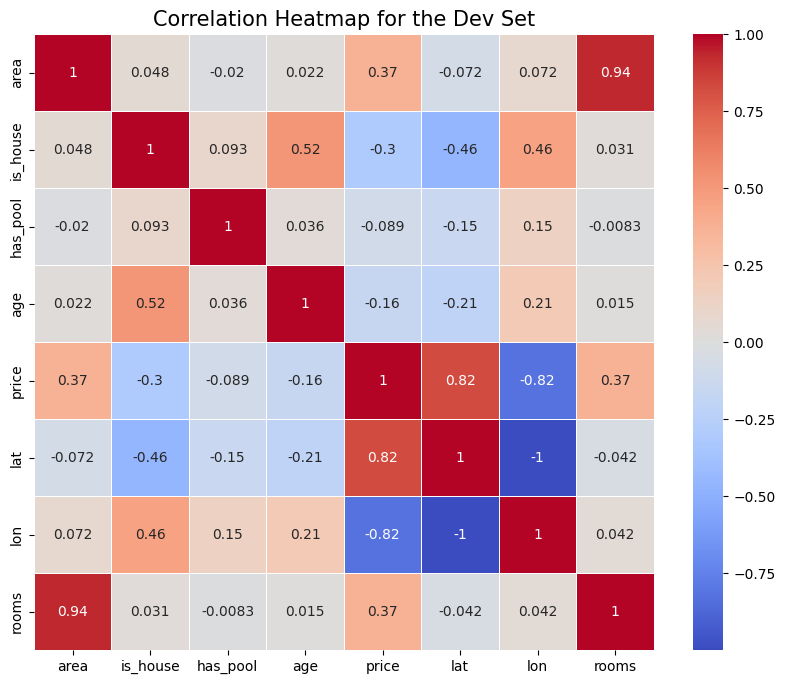

In [17]:
plot_correlation(units_converted_dev_df, "the Dev Set")

#### 1.3) Separación en Train y Validation

Para evitar leaking, separamos el dataset en train y validation antes de estandarizar/escalar los datos y acomodar los valores faltantes.

In [18]:
from src.data_splitting import split_and_save_train_val

In [19]:
casas_train_df, casas_val_df = split_and_save_train_val(units_converted_dev_df, "raw/casas_train.csv", "raw/casas_val.csv")

Train set: 720 rows, Validation set: 180 rows


La idea de estandarización/escalamiento que se va a usar es la siguiente:

#### estandarizamos o escalamos los datos según corresponde

hacemos estandarización **`(Z-score normalization)`** cuando asumimos que los datos provienenen de una distribución aproximadamente normal
$$x' = \frac{x - \mu}{\sigma}$$

Y hacemos reescalado cuando cuando los datos no son normales  
Una opción común es **`Min-Max Scaling`**:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

A partir de la observación de la distribución de las variables decido hacer lo siguiente:  

Estandarizo:  
`age` (aproximadamente normal), `rooms` (discreta pero la estandarización ayuda)  
(luego de resolver el problema de los NaNs)

Reescalo:   
`area` y `price` están sesgadas a la derecha (colas largas)  

No hago nada con las binarias: `has_pool`, `is_house` 
`lat` y `lon` las analizaremos más adelante con feature engenieering

aún no estandarizamos porque al hacer las regresiones para estimar las variables, voy a dividir el dataset de train a su vez en train, validation y test, entonces si estandarizo ahora estaría filtrando información de los datos. Pero dentro de las funciones, esta es la lógica usada para estandarizar los datos para conseguir los valores faltantes.

#### 1.1) Segunda parte

#### Solucionamos ahora los problemas de nulls

##### `Rooms`

-> idea: estimo la cantidad de rooms en base al área

visualizo la relación para ver qué regresión usar

In [20]:
from src.plotting import plot_rooms_vs_area

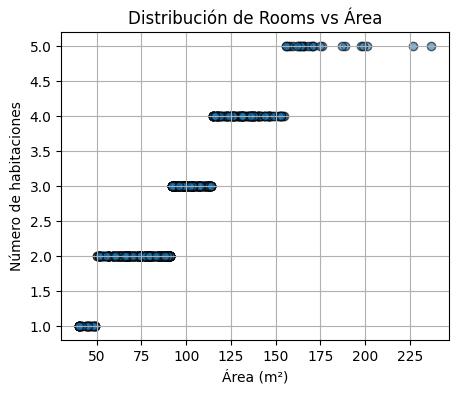

In [21]:
plot_rooms_vs_area(casas_train_df)

In [22]:
from src.models import predict_rooms_train_test, predict_rooms_no_split, complete_missing_rooms_values
from src.utils import missing_values_in_column

In [23]:
# print("Entrenamiento con Train set\n")
# print("divididendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)")
# predict_rooms_train_test(casas_train_df)
# print("\nentrenando con todo el dataset de train_df")
# W_d, b_d, mean_d, std_d = predict_rooms_no_split(casas_train_df)

# # uso los pesos de train para predecir en todos los datasets!!
# print("\nCompletando valores faltantes en todos los datasets con las métricas calculadas a partir de train_df")
# casas_train_rooms_complete = complete_missing_rooms_values(casas_train_df, W_d, b_d, mean_d, std_d)
# casas_val_rooms_complete = complete_missing_rooms_values(casas_val_df, W_d, b_d, mean_d, std_d)
# casas_test_rooms_complete = complete_missing_rooms_values(casas_test_df, W_d, b_d, mean_d, std_d)

# print("\nChequeo")
# print("Train:", missinng_values_in_column(casas_train_rooms_complete, 'rooms'))
# print("Validation:", missinng_values_in_column(casas_val_rooms_complete, 'rooms'))
# print("Test:", missinng_values_in_column(casas_test_rooms_complete, 'rooms'))

print("Entrenamiento con Train set\n")
print("Dividiendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)")
W_d, b_d, mean_d, std_d, min_d, max_d = predict_rooms_train_test(casas_train_df)

print("\nEntrenando con todo el dataset de train_df")
W_d, b_d, mean_d, std_d, min_d, max_d = predict_rooms_no_split(casas_train_df)

# Uso los pesos de train para predecir en todos los datasets
print("\nCompletando valores faltantes en todos los datasets con las métricas calculadas a partir de train_df")
casas_train_rooms_complete = complete_missing_rooms_values(casas_train_df, W_d, b_d, mean_d, std_d, min_d, max_d)
casas_val_rooms_complete = complete_missing_rooms_values(casas_val_df, W_d, b_d, mean_d, std_d, min_d, max_d)
casas_test_rooms_complete = complete_missing_rooms_values(units_converted_test_df, W_d, b_d, mean_d, std_d, min_d, max_d)

print("\nChequeo")
print("Train:", missing_values_in_column(casas_train_rooms_complete, 'rooms'))
print("Validation:", missing_values_in_column(casas_val_rooms_complete, 'rooms'))
print("Test:", missing_values_in_column(casas_test_rooms_complete, 'rooms'))




Entrenamiento con Train set

Dividiendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)
Época 0, Pérdida Train: 0.3219, Pérdida Val: 0.3217
Época 5000, Pérdida Train: 0.1744, Pérdida Val: 0.1648
Época 10000, Pérdida Train: 0.1505, Pérdida Val: 0.1440
Época 15000, Pérdida Train: 0.1357, Pérdida Val: 0.1308
Época 20000, Pérdida Train: 0.1250, Pérdida Val: 0.1212
Época 25000, Pérdida Train: 0.1168, Pérdida Val: 0.1137
Precisión en el conjunto de prueba de train_df: 0.8797

Entrenando con todo el dataset de train_df
Época 0, Pérdida Train: 0.3220, Pérdida Val: 0.3219
Época 5000, Pérdida Train: 0.1700, Pérdida Val: 0.1700
Época 10000, Pérdida Train: 0.1472, Pérdida Val: 0.1456
Época 15000, Pérdida Train: 0.1328, Pérdida Val: 0.1301
Época 20000, Pérdida Train: 0.1224, Pérdida Val: 0.1191
Época 25000, Pérdida Train: 0.1144, Pérdida Val: 0.1108

Completando valores faltantes en todos los datasets con las métricas calculadas a partir de t

verifico que las variables utilizadas normalizadas en la estimación estén en la escala real (area y rooms)

##### `Age`

estimo las ages que faltan, con aprendizaje supervisado utilizando las features que más correlacion en módulo tienen con age $\rightarrow$ is_house, price, area

In [24]:
from src.plotting import plot_age_vs

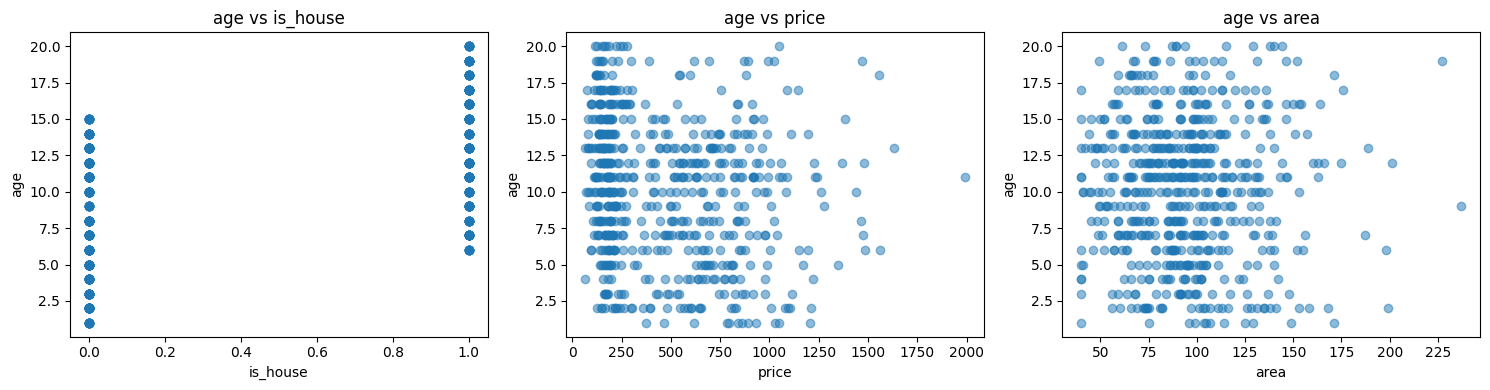

In [25]:
plot_age_vs(casas_train_rooms_complete, features=["is_house", "price", "area"])

In [26]:
from src.models import train_regression_for_age, complete_missing_age_values, evaluate_and_impute

In [27]:
features_seleccionadas = ['is_house', 'price', 'area']

# Indices de columnas para estandarizar/escalar
standardize_cols = []  # No hay columnas que necesiten estandarización (media 0, std 1)
scale_cols = [1, 2]  # 'price' y 'area' necesitan Min-Max Scaling (indices basados en features_seleccionadas)

print("Entrenamiento con Train set\n")
print("Dividiendo el dataset para obtener métricas de precisión (haciendo split dentro de train_df)")
casas_train_rooms_complete = evaluate_and_impute(casas_train_rooms_complete, features_seleccionadas, standardize_cols, scale_cols, grado=1)

# Entrenar con todo el dataset disponible
theta_final, mean_final, std_final, min_final, max_final = train_regression_for_age(
    casas_train_rooms_complete, features_seleccionadas, standardize_cols, scale_cols, grado=1
)

# Imputar valores faltantes en los distintos datasets
casas_train_complete = complete_missing_age_values(
    casas_train_rooms_complete, theta_final, mean_final, std_final, min_final, max_final, features_seleccionadas, standardize_cols, scale_cols, grado=1
)
casas_val_complete = complete_missing_age_values(
    casas_val_rooms_complete, theta_final, mean_final, std_final, min_final, max_final, features_seleccionadas, standardize_cols, scale_cols, grado=1
)
casas_test_complete = complete_missing_age_values(
    casas_test_rooms_complete, theta_final, mean_final, std_final, min_final, max_final, features_seleccionadas, standardize_cols, scale_cols, grado=1
)


Entrenamiento con Train set

Dividiendo el dataset para obtener métricas de precisión (haciendo split dentro de train_df)
Train RMSE: 4.0405
Validation RMSE: 3.7051
Test RMSE: 4.2650
107 valores faltantes en 'age' completados.
No hay valores faltantes en 'age'.
23 valores faltantes en 'age' completados.
16 valores faltantes en 'age' completados.


In [28]:
casas_train_complete.sample(15)

,area,is_house,has_pool,age,price,lat,lon,rooms
307,94.017968,0,0,9.0,689.0,40.720028,-73.952875,3.0
149,113.000000,1,0,17.0,196.0,-34.585988,-58.415250,3.0
749,75.000000,1,0,12.0,136.0,-34.681287,-58.404594,2.0
259,103.029571,0,0,2.0,820.0,40.723008,-73.988080,3.0
781,159.979190,1,0,12.0,1480.0,40.743194,-74.018666,3.0
879,86.957330,0,0,6.0,690.0,40.712557,-73.998682,2.0
836,85.006364,0,0,8.0,665.0,40.706793,-74.000989,2.0
254,90.000000,1,0,13.0,156.0,-34.686202,-58.375785,2.0
352,68.005091,0,0,8.0,506.0,40.691322,-73.965570,2.0
30,104.980537,0,0,5.0,814.0,40.720312,-73.996595,3.0


In [29]:
print("Valores faltantes después de la imputación:")
print("Train")
missing_values(casas_train_complete)
print("Validation")
missing_values(casas_val_complete)  
print("Test")
missing_values(casas_test_complete)

Valores faltantes después de la imputación:
Train

Valores faltantes por columna:
area        0
is_house    0
has_pool    0
age         0
price       0
lat         0
lon         0
rooms       0
dtype: int64
Validation

Valores faltantes por columna:
area        0
is_house    0
has_pool    0
age         0
price       0
lat         0
lon         0
rooms       0
dtype: int64
Test

Valores faltantes por columna:
area        0
is_house    0
has_pool    0
age         0
price       0
lat         0
lon         0
rooms       0
dtype: int64


Reviso no haber tocado nada del set de test más allá de los NaNs

In [30]:
age_comparison = casas_test_df['age'] == casas_test_complete['age']
rooms_comparison = casas_test_df['rooms'] == casas_test_complete['rooms']

print("Comparación de la columna 'age':")
print(age_comparison.value_counts())  

print("\nComparación de la columna 'rooms':")
print(rooms_comparison.value_counts())

print("\nFilas donde 'age' no coincide:")
print(casas_test_df[~age_comparison])

print("\nFilas donde 'rooms' no coincide:")
print(casas_test_df[~rooms_comparison])

Comparación de la columna 'age':
age
True     84
False    16
Name: count, dtype: int64

Comparación de la columna 'rooms':
rooms
True     96
False     4
Name: count, dtype: int64

Filas donde 'age' no coincide:
      area area_units  is_house  has_pool  age   price        lat        lon  \
13   667.0       sqft         0         0  NaN   480.0  40.708612 -74.023947   
16   926.0       sqft         0         0  NaN   642.0  40.723940 -73.988968   
28    89.0         m2         1         0  NaN   161.0 -34.537603 -58.385514   
32   678.0       sqft         0         0  NaN   470.0  40.739068 -73.982893   
41   129.0         m2         1         0  NaN   225.0 -34.562169 -58.404882   
60    97.0         m2         1         0  NaN   188.0 -34.557143 -58.372201   
62  1023.0       sqft         0         0  NaN   747.0  40.689159 -74.007984   
63    79.0         m2         0         0  NaN   124.0 -34.632125 -58.444064   
66  1109.0       sqft         0         0  NaN   791.0  40.709839 -73

está bien, solo difieren en los que eran NaNs

##### el set de test que voy a usar es el original, solo que con las columnas de 'age' y 'rooms' completadas en los valores NaNs

In [31]:
casas_test_df['age'] = casas_test_complete['age']
casas_test_df['rooms'] = casas_test_complete['rooms']

ahora sí normalizamos train y validation

#### 1.3) Segunda Parte

In [32]:
from src.preprocessing import compute_statistics, scale_df

In [33]:
train_stats = compute_statistics(casas_train_df)

casas_train_transformed = scale_df(casas_train_df, train_stats)
casas_val_transformed = scale_df(casas_val_df, train_stats) # uso las estadísticas de train!!!

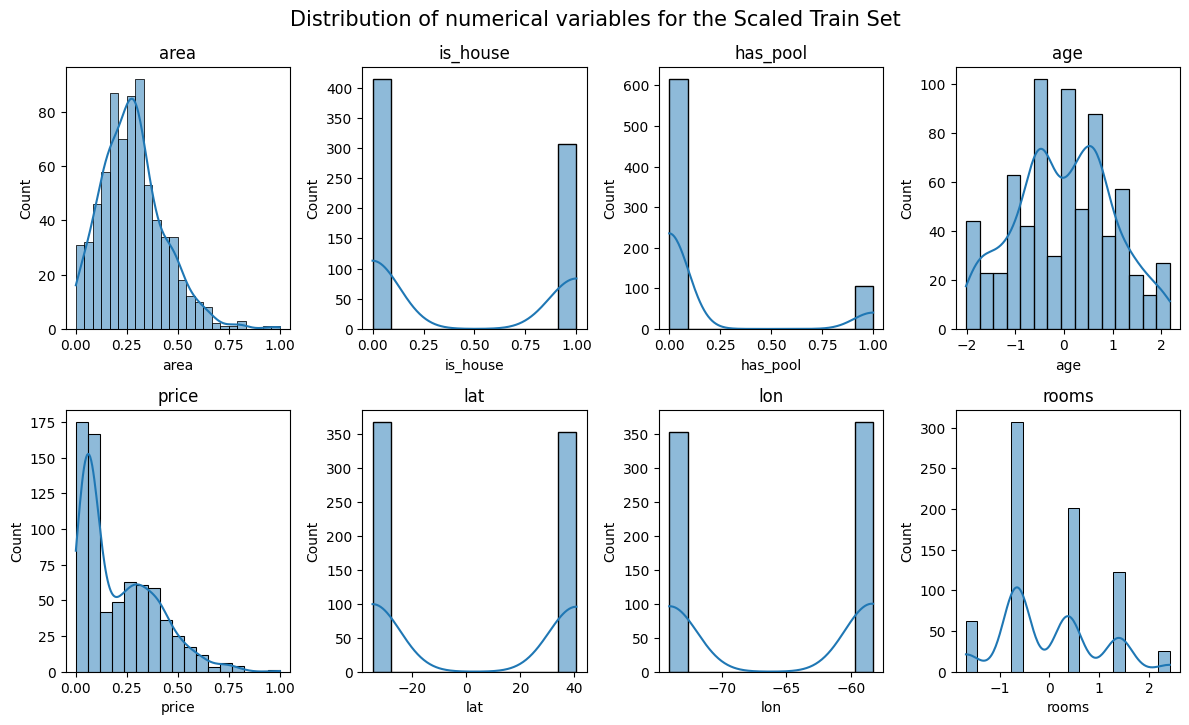

In [34]:
plot_distributions(casas_train_transformed, "Scaled Train")

(área y price siguen la misma distribución pero están entre 0 y 1)

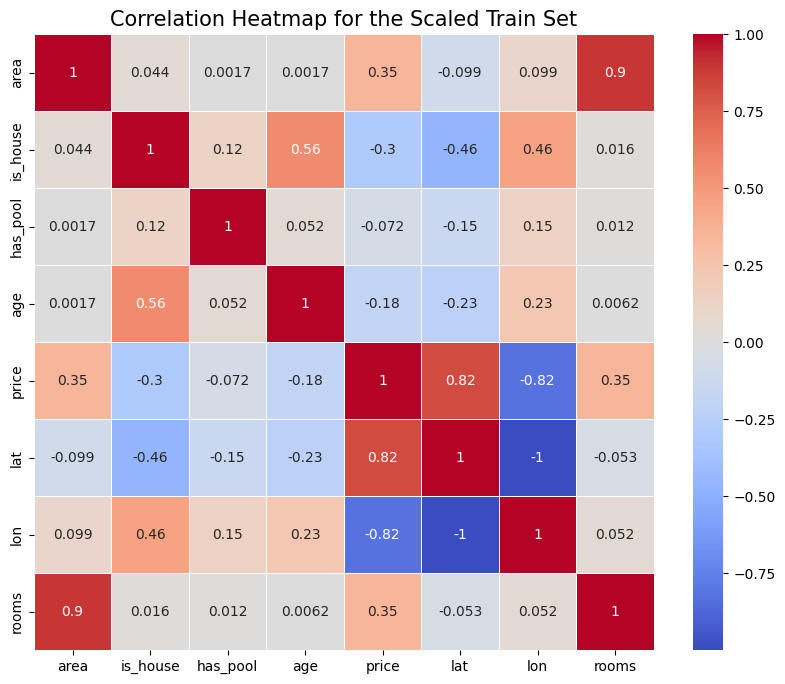

In [35]:

plot_correlation(casas_train_transformed, "the Scaled Train Set")

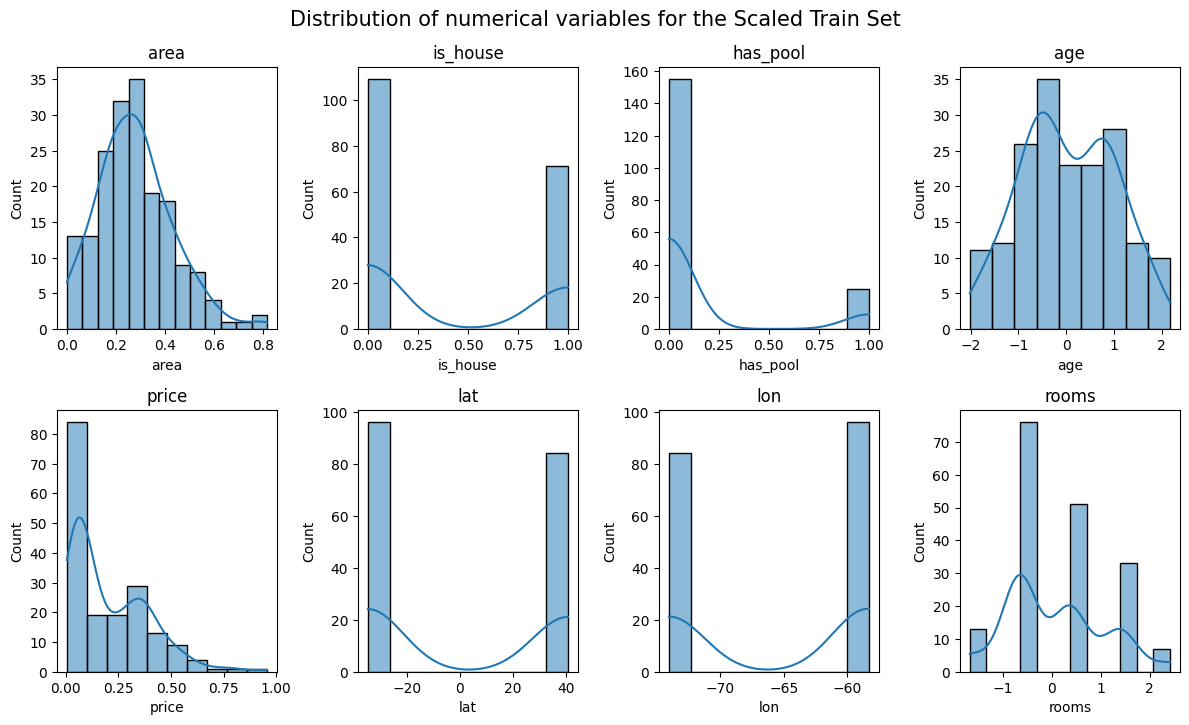

In [36]:
plot_distributions(casas_val_transformed, "Scaled Train")

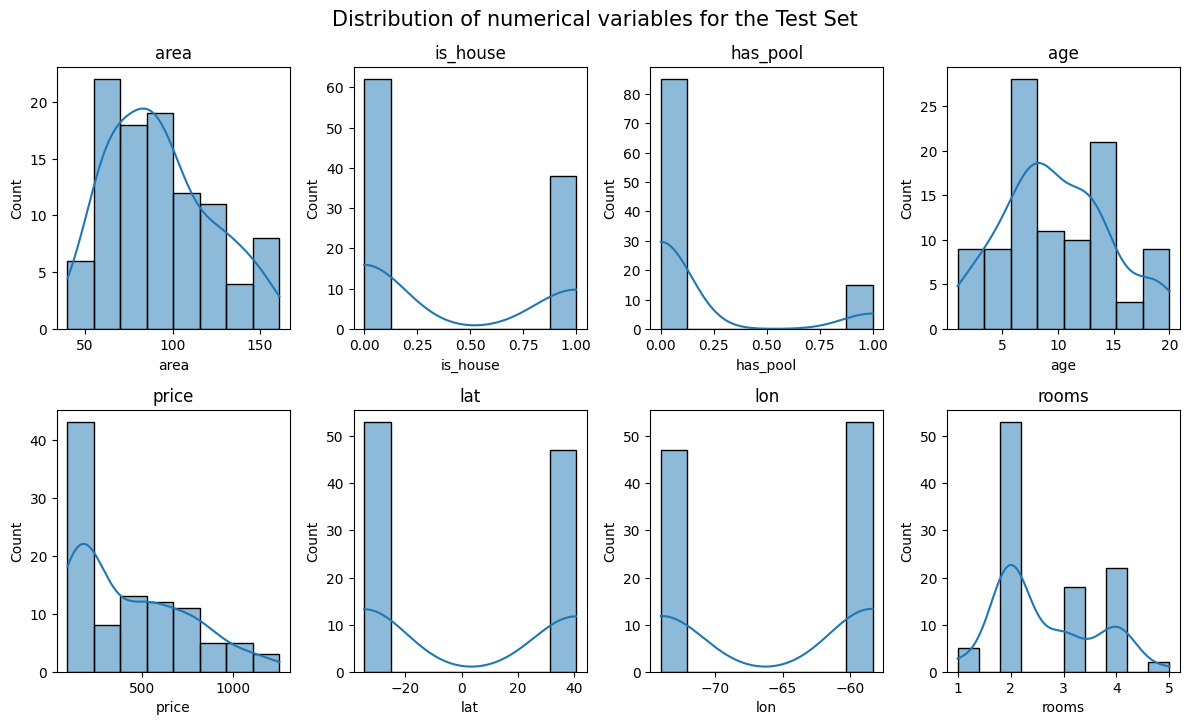

In [37]:
plot_distributions(casas_test_complete, "Test")

guardo los datasets para no tener que recalcularlos cada vez que los necesite y no pisar variables en el notebook

In [38]:
from src.utils import save_csv

save_csv(casas_train_transformed, "data/processed/casas_train_filled_n_normalized.csv")
save_csv(casas_val_transformed, "data/processed/casas_val_filled_n_normalized.csv")

save_csv(casas_train_df, "data/processed/casas_train_filled.csv")
save_csv(casas_val_df, "data/processed/casas_val_filled.csv")
save_csv(casas_test_df, "data/processed/casas_test_filled.csv")


Dataset guardado como 'data/processed/casas_train_filled_n_normalized.csv'.
Dataset guardado como 'data/processed/casas_val_filled_n_normalized.csv'.
Dataset guardado como 'data/processed/casas_train_filled.csv'.
Dataset guardado como 'data/processed/casas_val_filled.csv'.
Dataset guardado como 'data/processed/casas_test_filled.csv'.


# 2) Implementación de Regresión Lineal

#### 2.1) implementación de la clase Linear Regression en src.models

#### 2.2) implementación de RMSE en src.metrics

#### 2.3)

In [39]:
from src.models import LinearRegression
from src.utils import load_data

In [40]:
use_already_scaled = False # False para escalar dentro de la clase LinearRegression -> para pasarle el set de test como está

dir_base = "data/processed/"

if not use_already_scaled:
    train_path = dir_base + "casas_train_filled.csv"
    validation_path = dir_base + "casas_val_filled.csv"
else:
    train_path = dir_base + "casas_train_filled_n_normalized.csv"
    validation_path = dir_base + "casas_val_filled_n_normalized.csv"
    
test_path = dir_base + "casas_test_filled.csv"


def use_test(test_path, is_scaled=False, train_stats=None):
    test = pd.read_csv(test_path)
    test = area_units_conversion(test)
    
    if is_scaled:
       test = scale_df(test, train_stats, True) # no lo voy a usar
       
    return test

test = use_test(test_path, use_already_scaled, train_stats)

features = ["area", "is_house", "has_pool", "age", "lat", "lon", "rooms"] 
target = "price"

X_train, y_train = load_data(train_path, None, features, target)
X_val, y_val = load_data(validation_path, None, features, target)
X_test, y_test = load_data("", test, features, target, True)


#### Prueba con una característica

In [41]:
X_train_1 = X_train[:, [6]]  # solo rooms
X_val_1 = X_val[:, [6]]  
X_test_1 = X_test[:, [6]]

##### Pseudoinversa

Error cuadrático medio (MSE) en test: 86440.4376


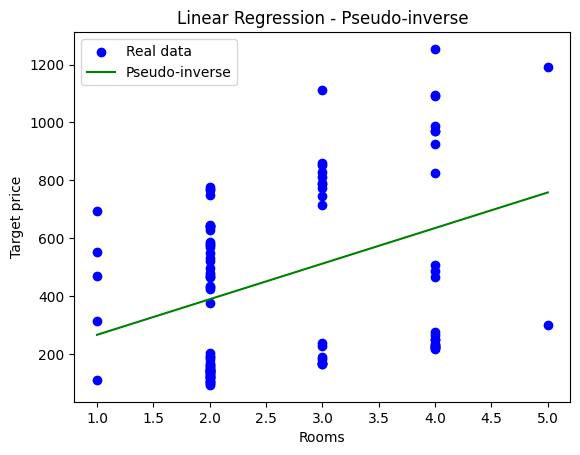

In [42]:
model_one_feature_pinv = LinearRegression(X_train_1, y_train, X_val_1, y_val, ["rooms"])
model_one_feature_pinv.entrenar_pseudoinversa()
model_one_feature_pinv.evaluar(X_test_1, y_test)
model_one_feature_pinv.graficar_regresion_pseudoinversa(X_test_1, y_test, ["Rooms"])

##### Descenso por gradiente

Early stopping en epoch 334
Error cuadrático medio (MSE) en test: 85665.1210


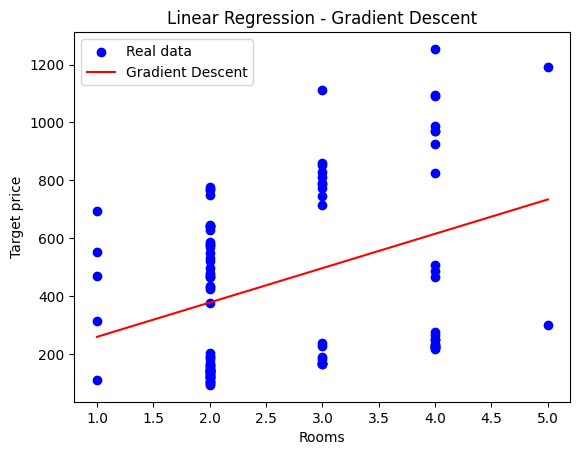

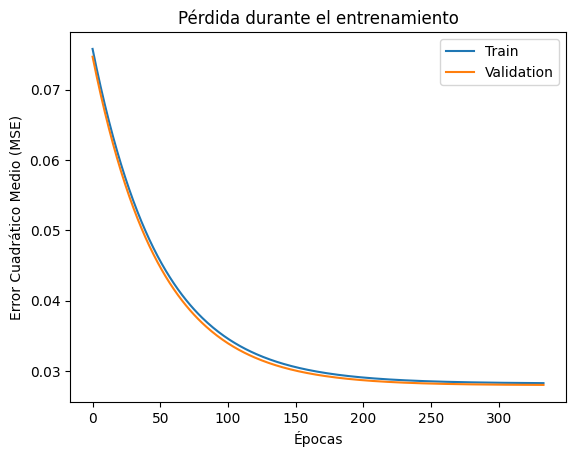

In [43]:
model_one_feature_gd = LinearRegression(X_train_1, y_train, X_val_1, y_val, ["rooms"])
model_one_feature_gd.entrenar_descenso_gradiente(lr=0.01, epochs=5000)
model_one_feature_gd.evaluar(X_test_1, y_test)
model_one_feature_gd.graficar_regresion_descenso_gradiente(X_test_1, y_test, ["Rooms"])
model_one_feature_gd.graficar_perdida()

#### Prueba con múltiples características

##### Pseudoinversa

In [44]:
model_multi_pinv = LinearRegression(X_train, y_train, X_val, y_val, features)
model_multi_pinv.entrenar_pseudoinversa()
model_multi_pinv.evaluar(X_test, y_test)

Error cuadrático medio (MSE) en test: 12373.5585


12373.558474124568

##### Descenso por gradiente

Early stopping en epoch 276
Error cuadrático medio (MSE) en test: 28573.5697


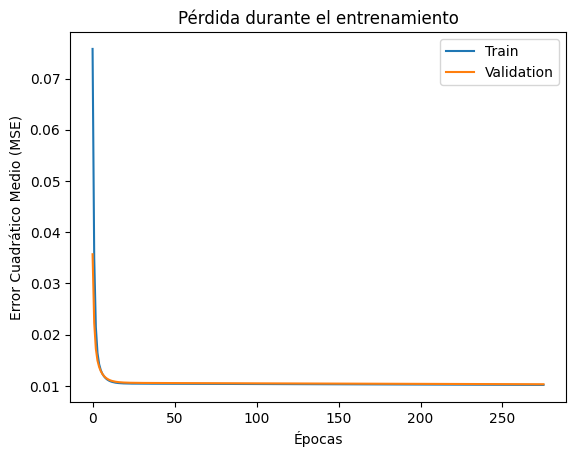

In [45]:
model_multi_gd = LinearRegression(X_train, y_train, X_val, y_val, features)
model_multi_gd.entrenar_descenso_gradiente(lr=0.0001, epochs=5000)
model_multi_gd.evaluar(X_test, y_test)
model_multi_gd.graficar_perdida()


En el caso general, el método de `la pseudoinversa tiene menos Error Cuadrático Medio` en el set de test.  
En el ejemplo de una variable, descenso por gradiente tuvo una mejor performance en el set de test en cuánto a la métrica MSE.

# 3) Aplicación del Modelo de Regresión

#### 3.1)

Error cuadrático medio (MSE) en test: 84953.1090


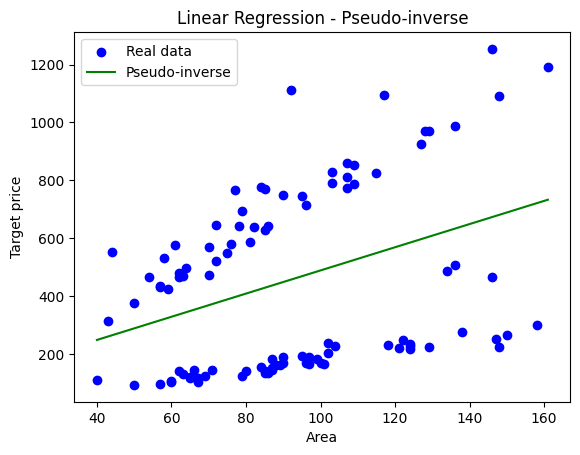

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_train_1 = X_train[:, [0]]  # solo area
X_val_1 = X_val[:, [0]]  
X_test_1 = X_test[:, [0]]

model_area_pinv = LinearRegression(X_train_1, y_train, X_val_1, y_val, ["area"])
model_area_pinv.entrenar_pseudoinversa()
model_area_pinv.evaluar(X_test_1, y_test)
model_area_pinv.graficar_regresion_pseudoinversa(X_test_1, y_test, ["Area"])


#### 3.2)

In [47]:
from src.utils import select_features

In [48]:
relevant_features = ["area", "has_pool", "lat", "lon", "rooms"] 

X_train_subset, X_val_subset, X_test_subset = select_features(relevant_features, features, X_train, X_val, X_test)

In [49]:
model_selected_features_pinv = LinearRegression(X_train_subset, y_train, X_val_subset, y_val, relevant_features)
model_selected_features_pinv.entrenar_pseudoinversa()
model_selected_features_pinv.evaluar(X_test_subset, y_test)

Error cuadrático medio (MSE) en test: 11941.4692


11941.469154463524

In [50]:
amanda_path = 'data/raw/vivienda_Amanda.csv'
amanda_df = pd.read_csv(amanda_path)
amanda_df = area_units_conversion(amanda_df)
amanda_df.head()

,area,is_house,has_pool,age,lat,lon,rooms
0,103.958602,0,0,11.0,40.675423,-74.012999,3


In [51]:
amanda_features = amanda_df[relevant_features].values
predicted_price_selected_features = model_selected_features_pinv.predecir(amanda_features)
print(f"El precio predicho con la selección de features para la vivienda de Amanda es: {predicted_price_selected_features[0]:.2f}")

El precio predicho con la selección de features para la vivienda de Amanda es: 811.36


In [52]:
predicted_price_all_features = model_multi_pinv.predecir(amanda_df.values)
print(f"El precio predicho con todas las features para la vivienda de Amanda es: {predicted_price_all_features[0]:.2f}")

El precio predicho con todas las features para la vivienda de Amanda es: 788.91


El `precio predicho` con el modelo de la pseudoinversa usando la selección de features `para la vivienda de Amanda es:` **`811.36`**

#### 3.3) Valor promedio por metro cuadrado de una casa

In [53]:
train_path = dir_base + "casas_train_filled.csv"
df_houses = pd.read_csv(train_path)
df_houses = df_houses[df_houses['is_house'] == 1]
price_per_m2 = df_houses['price'] / df_houses['area']

print("Valor promedio por metro cuadrado de una casa:", price_per_m2.mean())

Valor promedio por metro cuadrado de una casa: 3.634511450216048


`El valor promedio por metro cuadrado de una casa es` **`3.634511450216048`**

#### 3.4) Impacto de la construcción de una pileta en el precio de su propiedad

In [54]:
coeficientes = model_multi_pinv.coef
coef_dict = dict(zip(["intercept"] + features, coeficientes))
print(f"Coeficiente de has_pool: {coef_dict['has_pool']:.2f}")


Coeficiente de has_pool: 0.02


El coeficiente de has_pool es 0.02, lo que indica que `agregar una pileta incrementa el precio de la propiedad en un 2% del rango de precios normalizado`

Impacto real:  
$\Delta \text{precio real} = 0.02 × (\text{precio máximo} − \text{precio mínimo})$

In [55]:
price_min = model_multi_pinv.stats["price"]["min"]
price_max = model_multi_pinv.stats["price"]["max"]

impacto_real = 0.02 * (price_max - price_min)
print(f"Impacto estimado en unidades monetarias: {impacto_real:.2f}")

Impacto estimado en unidades monetarias: 38.54


A nivel precio real, tener pileta incrementría aproximadamente `38.54` unidades

## 4) Feature Engineering

#### 4.1)

#### Ubicación:
- **`geo_angle`**: `arctan(lat / lon)` → Captura la orientación relativa de la casa en el espacio.
- **`dist_to_cluster_centroid`**: Distancia al centroide de su zona.
- **`pca_lat_lon`**: Coordenadas geográficas transformadas con seno/coseno (por ciclicidad) y PCA entre ellas para capturar variabilidad espacial.
- **`cluster_id`**: Identificador del cluster de la propiedad según ubicación.

#### Transformaciones no lineales:
- **`log_area_plus_1`**: `log(area + 1)` → Comprime valores altos y expande bajos, útil para datos sesgados a la derecha.
- **`age_2`, `area_2`, `distance_to_center_2`**: Capturan relaciones cuadráticas que pueden ser relevantes en el modelo.

#### Interacciones y relaciones:
- **`rooms_distance_interaction`**: Captura si casas más alejadas suelen ser más grandes o más chicas.
- **`rooms_age_interaction`**: Captura si casas con más habitaciones tienden a ser más viejas.
- **`m2_per_room`**: Espacio por habitación.
- **`room_density`**: `rooms / sqrt(area)` → Cuán densamente están distribuidas las habitaciones sin ser la inversa de `m2_per_room` para evitar colinealidad.
- **`distance_per_age`**: Captura si las propiedades más nuevas o más viejas tienden a estar más cerca o más alejadas del centro.

#### Variables binarias:
- **`is_new`**: `1` si la casa tiene ≤5 años.
- **`is_old`**: `1` si la casa tiene >30 años.
- **`is_big`**: `1` si el área es mayor que la mediana del dataset.
- **`is_near_centertroid`**: `1` si está más cerca que la distancia mediana al centro de su ciudad.
- **`is_new_relative`**: `1` si la casa es más nueva que la mediana de su zona.



In [56]:
from src.utils import hist_plot

`Geográficas`

In [57]:
from src.feature_engineering import pca_latlon, kmeans, assign_to_cluster, distance_to_centroid

In [58]:
dir_base = "data/processed/"

train_path = dir_base + "casas_train_filled.csv"
validation_path = dir_base + "casas_val_filled.csv"    
test_path = dir_base + "casas_test_filled.csv"

casas_train_df = pd.read_csv(train_path)
casas_val_df = pd.read_csv(validation_path)
casas_test_df = use_test(test_path)

lat_lon_train = casas_train_df[['lat', 'lon']].values
lat_lon_val = casas_val_df[['lat', 'lon']].values
lat_lon_test = casas_test_df[['lat', 'lon']].values

# K-Means
np.random.seed(42)
centroids = lat_lon_train[np.random.choice(len(lat_lon_train), 2, replace=False)]

train_labels, final_centroids = kmeans(lat_lon_train, k=2) # los centroides se calculan con train
centroids_dict = {i: final_centroids[i] for i in range(2)}

val_labels = np.array([assign_to_cluster(p, centroids_dict) for p in lat_lon_val])
test_labels = np.array([assign_to_cluster(p, centroids_dict) for p in lat_lon_test])


casas_train_df['cluster_id'] = train_labels
casas_val_df['cluster_id'] = val_labels
casas_test_df['cluster_id'] = test_labels

train_distances = distance_to_centroid(train_labels, lat_lon_train, centroids_dict)
val_distances = distance_to_centroid(val_labels, lat_lon_val, centroids_dict)
test_distances = distance_to_centroid(test_labels, lat_lon_test, centroids_dict)


casas_train_df['dist_to_cluster_centroid'] = train_distances
casas_val_df['dist_to_cluster_centroid'] = val_distances
casas_test_df['dist_to_cluster_centroid'] = test_distances

Resumen de clusters

            count      mean
cluster_id                 
0             367  4.671766
1             353  2.659845


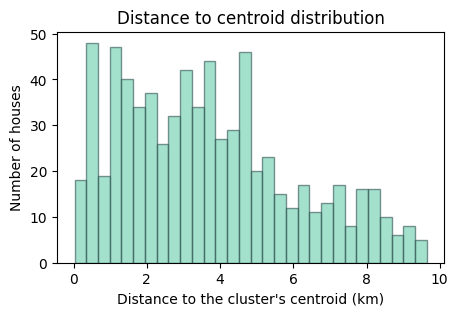

In [59]:
train_clusters_summary = casas_train_df.groupby("cluster_id")['dist_to_cluster_centroid'].agg(['count', 'mean'])
train_clusters_summary = train_clusters_summary[train_clusters_summary['count'] > 0]
print(train_clusters_summary)


plt.figure(figsize=(5, 3))
plt.hist(casas_train_df['dist_to_cluster_centroid'].dropna(), bins=30, color="mediumaquamarine", edgecolor="darkslategrey", alpha=0.6)
plt.xlabel("Distance to the cluster's centroid (km)")
plt.ylabel("Number of houses")
plt.title("Distance to centroid distribution")
plt.show()


In [60]:
casas_train_df = pca_latlon(casas_train_df)
casas_val_df = pca_latlon(casas_val_df)    
casas_test_df = pca_latlon(casas_test_df)

casas_train_df.head()


Varianza explicada por cada componente: [[0.89307106 0.        ]
 [0.         0.10692894]]
Varianza explicada por cada componente: [[0.88582573 0.        ]
 [0.         0.11417427]]
Varianza explicada por cada componente: [[0.88687531 0.        ]
 [0.         0.11312469]]


,area,is_house,has_pool,age,price,lat,lon,rooms,cluster_id,dist_to_cluster_centroid,pca_latlon_1
0,81.011529,0,0,11.0,630.0,40.718433,-74.008699,2.0,1,1.064317,-1.277016
1,99.963768,0,0,7.0,772.0,40.707037,-73.998823,3.0,1,0.588810,-1.278153
2,137.000000,0,0,10.0,214.0,-34.550223,-58.391268,4.0,0,5.890130,-0.459670
3,71.999926,1,1,10.0,751.0,40.726223,-74.043929,2.0,1,3.772768,-1.281280
4,154.000000,1,0,16.0,273.0,-34.563525,-58.347365,4.0,0,5.341236,-0.470178


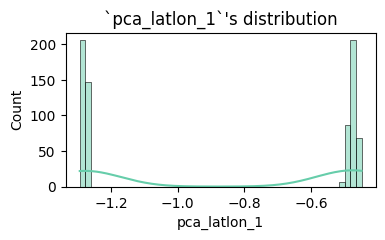

In [61]:
hist_plot(casas_train_df, 'pca_latlon_1')

In [62]:
casas_train_df['geo_angle'] = np.arctan(casas_train_df['lat'] / (casas_train_df['lon'] + 1e-6))
casas_val_df['geo_angle'] = np.arctan(casas_val_df['lat'] / (casas_val_df['lon'] + 1e-6))
casas_test_df['geo_angle'] = np.arctan(casas_test_df['lat'] / (casas_test_df['lon'] + 1e-6))


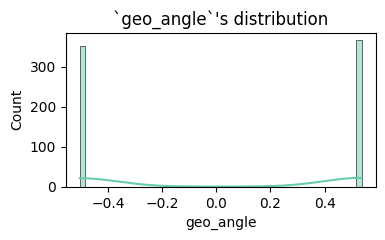

In [63]:
hist_plot(casas_train_df, 'geo_angle')

`Binarias`

In [64]:
median_distance = casas_train_df['dist_to_cluster_centroid'].median()

casas_train_df['is_near_centroid'] = (casas_train_df['dist_to_cluster_centroid'] < median_distance).astype(int)
casas_val_df['is_near_centroid'] = (casas_val_df['dist_to_cluster_centroid'] < median_distance).astype(int)
casas_test_df['is_near_centroid'] = (casas_test_df['dist_to_cluster_centroid'] < median_distance).astype(int)

casas_train_df[[ 'dist_to_cluster_centroid', 'is_near_centroid']].head()


,dist_to_cluster_centroid,is_near_centroid
0,1.064317,1
1,0.588810,1
2,5.890130,0
3,3.772768,0
4,5.341236,0


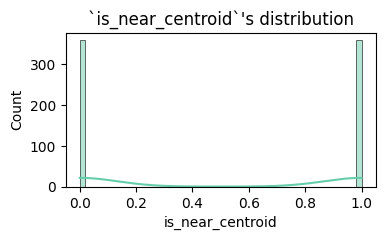

In [65]:
hist_plot(casas_train_df, 'is_near_centroid')

In [66]:
casas_train_df['is_new'] = (casas_train_df['age'] <= 5).astype(int)
casas_val_df['is_new'] = (casas_val_df['age'] <= 5).astype(int)
casas_test_df['is_new'] = (casas_test_df['age'] <= 5).astype(int)

casas_train_df[[ 'age', 'is_new']].head()

,age,is_new
0,11.0,0
1,7.0,0
2,10.0,0
3,10.0,0
4,16.0,0


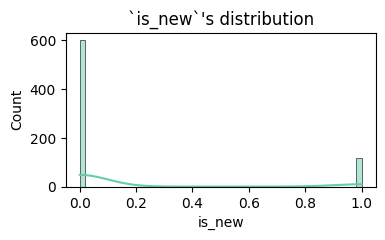

In [67]:
hist_plot(casas_train_df, 'is_new')

In [68]:
if any(casas_train_df['age'] >= 30) or any(casas_val_df['age'] >= 30) or any(casas_test_df['age'] >= 30):
    casas_train_df['is_old'] = (casas_train_df['age'] >= 30).astype(int)
    casas_val_df['is_old'] = (casas_val_df['age'] >= 30).astype(int)
    casas_test_df['is_old'] = (casas_test_df['age'] >= 30).astype(int)
    
    casas_train_df[[ 'age', 'is_old']].head()


In [69]:
median_area = casas_train_df['area'].median()

casas_train_df['is_big'] = (casas_train_df['area'] > median_area).astype(int)
casas_val_df['is_big'] = (casas_val_df['area'] > median_area).astype(int)
casas_test_df['is_big'] = (casas_test_df['area'] > median_area).astype(int)

casas_train_df[['area', 'is_big']].head()


,area,is_big
0,81.011529,0
1,99.963768,1
2,137.000000,1
3,71.999926,0
4,154.000000,1


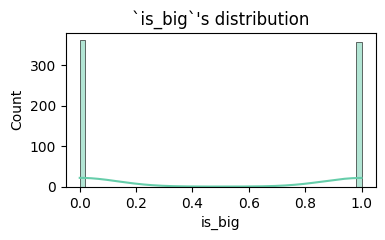

In [70]:
hist_plot(casas_train_df, 'is_big')

In [71]:
median_age_per_cluster = casas_train_df.groupby('cluster_id')['age'].median()

casas_train_df['is_new_relative'] = (casas_train_df['age'] < casas_train_df['cluster_id'].map(median_age_per_cluster)).astype(int)
casas_val_df['is_new_relative'] = (casas_val_df['age'] < casas_val_df['cluster_id'].map(median_age_per_cluster)).astype(int)
casas_test_df['is_new_relative'] = (casas_test_df['age'] < casas_test_df['cluster_id'].map(median_age_per_cluster)).astype(int)

casas_train_df[['age', 'cluster_id', 'is_new_relative']].head()

,age,cluster_id,is_new_relative
0,11.0,1,0
1,7.0,1,1
2,10.0,0,1
3,10.0,1,0
4,16.0,0,0


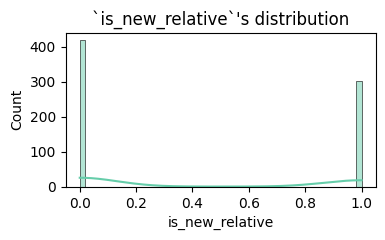

In [72]:
hist_plot(casas_train_df, 'is_new_relative')

`Relaciones e interacciones`

In [73]:
epsilon = 1e-6  # para evitar la divisón por 0

casas_train_df['m2_per_room'] = casas_train_df['area'] / (casas_train_df['rooms'] + epsilon)
casas_val_df['m2_per_room'] = casas_val_df['area'] / (casas_val_df['rooms'] + epsilon)
casas_test_df['m2_per_room'] = casas_test_df['area'] / (casas_test_df['rooms'] + epsilon)

m2_per_room_limits = casas_train_df['m2_per_room'].quantile([0.01, 0.99]) # limita valores extremos

casas_train_df['m2_per_room'] = casas_train_df['m2_per_room'].clip(*m2_per_room_limits)

casas_train_df[[ 'area', 'rooms', 'm2_per_room']].head()


,area,rooms,m2_per_room
0,81.011529,2.0,40.505744
1,99.963768,3.0,33.321245
2,137.000000,4.0,34.249991
3,71.999926,2.0,35.999945
4,154.000000,4.0,38.499990


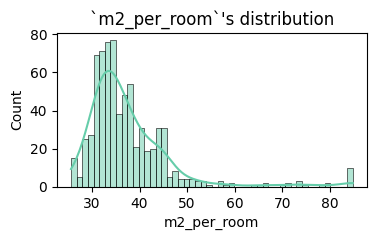

In [74]:
hist_plot(casas_train_df, 'm2_per_room')

In [75]:
casas_train_df['room_density'] = casas_train_df['rooms'] / np.sqrt(casas_train_df['area'] + 1e-6)
casas_val_df['room_density'] = casas_val_df['rooms'] / np.sqrt(casas_val_df['area'] + 1e-6)
casas_test_df['room_density'] = casas_test_df['rooms'] / np.sqrt(casas_test_df['area'] + 1e-6)

casas_train_df[['rooms', 'area', 'room_density']].head()

,rooms,area,room_density
0,2.0,81.011529,0.222206
1,3.0,99.963768,0.300054
2,4.0,137.000000,0.341743
3,2.0,71.999926,0.235702
4,4.0,154.000000,0.322329


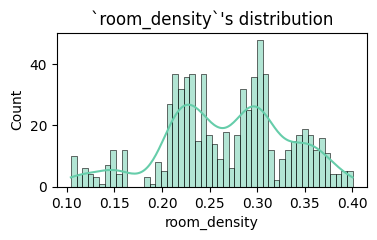

In [76]:
hist_plot(casas_train_df, 'room_density')

$\rightarrow$ en el modelo voy a estandarizar esta

In [77]:
casas_train_df['distance_per_age'] = casas_train_df['dist_to_cluster_centroid'] / (casas_train_df['age'] + epsilon)
casas_val_df['distance_per_age'] = casas_val_df['dist_to_cluster_centroid'] / (casas_val_df['age'] + epsilon)
casas_test_df['distance_per_age'] = casas_test_df['dist_to_cluster_centroid'] / (casas_test_df['age'] + epsilon)

casas_train_df[['dist_to_cluster_centroid', 'age', 'distance_per_age']].head()

,dist_to_cluster_centroid,age,distance_per_age
0,1.064317,11.0,0.096756
1,0.588810,7.0,0.084116
2,5.890130,10.0,0.589013
3,3.772768,10.0,0.377277
4,5.341236,16.0,0.333827


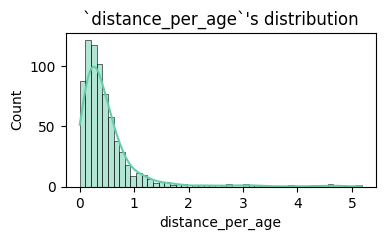

In [78]:
hist_plot(casas_train_df, 'distance_per_age')

In [79]:
casas_train_df['rooms_distance_interaction'] = casas_train_df['rooms'] * casas_train_df['dist_to_cluster_centroid']
casas_val_df['rooms_distance_interaction'] = casas_val_df['rooms'] * casas_val_df['dist_to_cluster_centroid']
casas_test_df['rooms_distance_interaction'] = casas_test_df['rooms'] * casas_test_df['dist_to_cluster_centroid']

casas_train_df[['rooms', 'dist_to_cluster_centroid', 'rooms_distance_interaction']].head()

,rooms,dist_to_cluster_centroid,rooms_distance_interaction
0,2.0,1.064317,2.128634
1,3.0,0.588810,1.766429
2,4.0,5.890130,23.560518
3,2.0,3.772768,7.545537
4,4.0,5.341236,21.364945


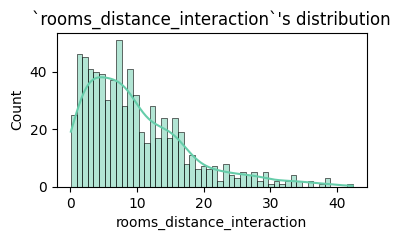

In [80]:
hist_plot(casas_train_df, 'rooms_distance_interaction')

In [81]:
casas_train_df['rooms_age_interaction'] = casas_train_df['rooms'] * casas_train_df['age']
casas_val_df['rooms_age_interaction'] = casas_val_df['rooms'] * casas_val_df['age']
casas_test_df['rooms_age_interaction'] = casas_test_df['rooms'] * casas_test_df['age']

casas_train_df[['rooms', 'age', 'rooms_age_interaction']].head()

,rooms,age,rooms_age_interaction
0,2.0,11.0,22.0
1,3.0,7.0,21.0
2,4.0,10.0,40.0
3,2.0,10.0,20.0
4,4.0,16.0,64.0


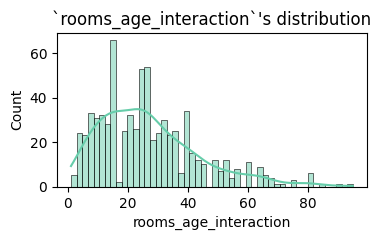

In [82]:
hist_plot(casas_train_df, 'rooms_age_interaction')

`Transformaciones no lineales`

In [83]:
casas_train_df['log_area_plus_1'] = np.log(casas_train_df['area'] + 1)
casas_val_df['log_area_plus_1'] = np.log(casas_val_df['area'] + 1)
casas_test_df['log_area_plus_1'] = np.log(casas_test_df['area'] + 1)

casas_train_df[['area', 'log_area_plus_1']].head()

,area,log_area_plus_1
0,81.011529,4.406860
1,99.963768,4.614762
2,137.000000,4.927254
3,71.999926,4.290458
4,154.000000,5.043425


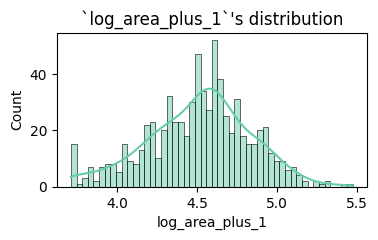

In [84]:
hist_plot(casas_train_df, 'log_area_plus_1')

$\rightarrow$ en el modelo voy a estandarizar

In [85]:
casas_train_df['log_m2_per_room'] = np.log(casas_train_df['m2_per_room'] + 1)
casas_val_df['log_m2_per_room'] = np.log(casas_val_df['m2_per_room'] + 1)
casas_test_df['log_m2_per_room'] = np.log(casas_test_df['m2_per_room'] + 1)

casas_train_df[['m2_per_room', 'log_m2_per_room']].head()

,m2_per_room,log_m2_per_room
0,40.505744,3.725832
1,33.321245,3.535765
2,34.249991,3.562465
3,35.999945,3.610916
4,38.499990,3.676300


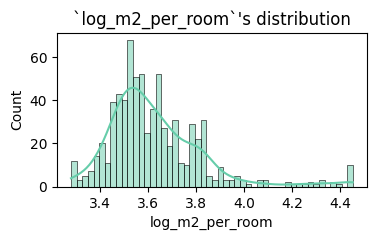

In [86]:
hist_plot(casas_train_df, 'log_m2_per_room')

In [87]:
casas_train_df['age_2'] = casas_train_df['age'] ** 2
casas_val_df['age_2'] = casas_val_df['age'] ** 2
casas_test_df['age_2'] = casas_test_df['age'] ** 2

casas_train_df['area_2'] = casas_train_df['area'] ** 2
casas_val_df['area_2'] = casas_val_df['area'] ** 2
casas_test_df['area_2'] = casas_test_df['area'] ** 2

casas_train_df['distance_to_center_2'] = casas_train_df['dist_to_cluster_centroid'] ** 2
casas_val_df['distance_to_center_2'] = casas_val_df['dist_to_cluster_centroid'] ** 2
casas_test_df['distance_to_center_2'] = casas_test_df['dist_to_cluster_centroid'] ** 2


casas_train_df[['age_2', 'area_2', 'distance_to_center_2']].head()

,age_2,area_2,distance_to_center_2
0,121.0,6562.867888,1.132771
1,49.0,9992.754887,0.346697
2,100.0,18769.000000,34.693627
3,100.0,5183.989307,14.233780
4,256.0,23716.000000,28.528805


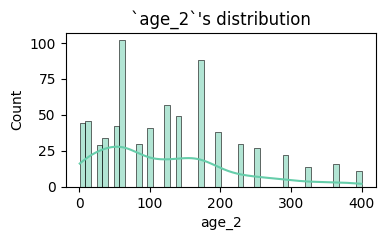

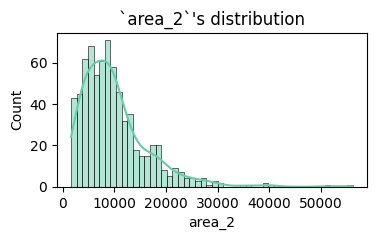

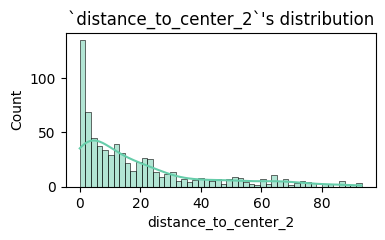

In [88]:
hist_plot(casas_train_df, 'age_2')
hist_plot(casas_train_df, 'area_2')
hist_plot(casas_train_df, 'distance_to_center_2')

In [89]:
casas_train_df.sample(5)

,area,is_house,has_pool,age,price,lat,lon,rooms,cluster_id,dist_to_cluster_centroid,...,m2_per_room,room_density,distance_per_age,rooms_distance_interaction,rooms_age_interaction,log_area_plus_1,log_m2_per_room,age_2,area_2,distance_to_center_2
290,89.000000,1,0,13.0,161.0,-34.628964,-58.380981,2.0,0,2.935912,...,44.499978,0.212000,0.225839,5.871825,26.0,4.499810,3.817712,169.0,7921.000000,8.619581
597,85.000000,1,1,11.0,176.0,-34.599824,-58.334325,2.0,0,4.315875,...,42.499979,0.216930,0.392352,8.631750,22.0,4.454347,3.772760,121.0,7225.000000,18.626776
293,75.994760,0,0,10.0,567.0,40.721339,-74.015481,2.0,1,1.601200,...,37.997361,0.229424,0.160120,3.202399,20.0,4.343737,3.663494,100.0,5775.203598,2.563840
614,95.039902,0,0,3.0,744.0,40.692270,-74.015529,3.0,1,2.079379,...,31.679957,0.307729,0.693126,6.238138,9.0,4.564764,3.486762,9.0,9032.582969,4.323818
695,66.983157,0,0,8.0,480.0,40.694723,-73.962411,2.0,1,3.949826,...,33.491562,0.244370,0.493728,7.899651,16.0,4.219260,3.540715,64.0,4486.743285,15.601122


In [90]:
casas_val_df.sample(5)

,area,is_house,has_pool,age,price,lat,lon,rooms,cluster_id,dist_to_cluster_centroid,...,m2_per_room,room_density,distance_per_age,rooms_distance_interaction,rooms_age_interaction,log_area_plus_1,log_m2_per_room,age_2,area_2,distance_to_center_2
78,82.033464,0,0,7.0,712.0,40.714598,-74.008820,2.0,1,0.670150,...,41.016711,0.220818,0.095736,1.340299,14.0,4.419244,3.738067,49.0,6729.489180,0.449100
33,126.000000,1,0,17.0,221.0,-34.666091,-58.385041,4.0,0,7.072130,...,31.499992,0.356348,0.416008,28.288520,68.0,4.844187,3.481240,289.0,15876.000000,50.015022
28,87.000000,0,0,3.0,183.0,-34.593028,-58.395887,2.0,0,1.700460,...,43.499978,0.214423,0.566820,3.400921,6.0,4.477337,3.795489,9.0,7569.000000,2.891566
10,124.000000,1,1,17.0,253.0,-34.547562,-58.375852,4.0,0,6.136536,...,30.999992,0.359211,0.360973,24.546143,68.0,4.828314,3.465736,289.0,15376.000000,37.657071
179,64.010257,0,1,9.0,535.0,40.731118,-73.996564,2.0,1,2.538390,...,32.005112,0.249980,0.282043,5.076779,18.0,4.174545,3.496662,81.0,4097.312946,6.443422


In [91]:
casas_test_df.sample(5)

,area,is_house,has_pool,age,price,lat,lon,rooms,cluster_id,dist_to_cluster_centroid,...,m2_per_room,room_density,distance_per_age,rooms_distance_interaction,rooms_age_interaction,log_area_plus_1,log_m2_per_room,age_2,area_2,distance_to_center_2
24,87.000000,1,0,20.0,145.0,-34.680562,-58.371240,2.0,0,8.722440,...,43.499978,0.214423,0.436122,17.444879,40.0,4.477337,3.795489,400.0,7569.000000,76.080954
58,150.000000,0,0,4.0,267.0,-34.595462,-58.342946,4.0,0,3.603690,...,37.499991,0.326599,0.900922,14.414761,16.0,5.017280,3.650658,16.0,22500.000000,12.986584
11,121.000000,1,0,12.0,219.0,-34.663708,-58.364555,4.0,0,6.970826,...,30.249992,0.363636,0.580902,27.883302,48.0,4.804021,3.442019,144.0,14641.000000,48.592409
46,71.999926,1,0,19.0,645.0,40.682022,-74.045498,2.0,1,4.551822,...,35.999945,0.235702,0.239570,9.103644,38.0,4.290458,3.610916,361.0,5183.989307,20.719085
90,115.014075,0,0,13.0,824.0,40.706070,-74.057209,4.0,1,4.400276,...,28.753512,0.372979,0.338483,17.601102,52.0,4.753712,3.392947,169.0,13228.237432,19.362425


guardo los datasets con las nuevas features

In [92]:
save_csv(casas_train_df, "data/processed/casas_train_featured.csv")
save_csv(casas_val_df, "data/processed/casas_val_featured.csv")
save_csv(casas_test_df, "data/processed/casas_test_featured.csv")

Dataset guardado como 'data/processed/casas_train_featured.csv'.
Dataset guardado como 'data/processed/casas_val_featured.csv'.
Dataset guardado como 'data/processed/casas_test_featured.csv'.


A partir de ver las distribuciones de las nuevas variables, hago lo siguiente en el modelo  

- estandarizo `log_area_plus_1` y `room_density`
- hago min-max scaling con el resto (excepto las binarias: `is_new`, `is_big`, `is_near_centertroid`, `is_new_relative`)

In [93]:
to_standarize = ["age", "rooms", "log_area_plus_1", "room_density"]

to_scale = ["area", "dist_to_cluster_centroid", "pca_latlon_1", "geo_angle", "m2_per_room", "room_density", "distance_per_age", 
            "rooms_distance_interaction", "rooms_age_interaction", "log_area_plus_1", "log_m2_per_room", "age_2", "area_2", "distance_to_center_2"]

#### 4.2) Regresión lineal con las nuevas features

In [94]:
train_path_featured = dir_base + "casas_train_featured.csv"
validation_path_featured = dir_base + "casas_val_featured.csv"    
test_path_featured = dir_base + "casas_test_featured.csv"

In [95]:
# features_f = [col for col in casas_train_df.columns if col != "price"]
features_f = ["area", "is_house", "has_pool", "lat", "lon", "age", "rooms", "cluster_id", "dist_to_cluster_centroid", "pca_latlon_1", 
            "geo_angle", "is_near_centroid", "is_new", "is_big", "is_new_relative", "m2_per_room", "room_density", "distance_per_age", 
            "rooms_distance_interaction", "rooms_age_interaction", "log_area_plus_1", "log_m2_per_room", "age_2", "area_2", 
            "distance_to_center_2"] # lo dejo así para que se vean todas las que quedaron

relevant_features_f = ["area", "is_house", "age", "rooms", "cluster_id", "dist_to_cluster_centroid", 
                     "is_near_centroid", "is_new", "is_big", "is_new_relative", "m2_per_room", "room_density", 
                     "distance_per_age", "rooms_distance_interaction", "rooms_age_interaction", "log_area_plus_1", "log_m2_per_room", 
                     "age_2", "area_2", "distance_to_center_2"] 

X_train_f, y_train_f = load_data(train_path_featured, None, features_f, target)
X_val_f, y_val_f = load_data(validation_path_featured, None, features_f, target)
X_test_f, y_test_f = load_data(test_path_featured, None, features_f, target)

X_train_subset_f, X_val_subset_f, X_test_subset_f = select_features(relevant_features_f, features_f, X_train_f, X_val_f, X_test_f)

model_f_pinv = LinearRegression(X_train_subset_f, y_train_f, X_val_subset_f, y_val_f, relevant_features_f, False, None, to_scale, to_standarize)
model_f_pinv.entrenar_pseudoinversa()
model_f_pinv.evaluar(X_test_subset_f, y_test_f)

Error cuadrático medio (MSE) en test: 8513.5565


8513.556460158168

#### 4.3) 300 nuevas features

In [96]:
from src.feature_engineering import generate_power_features

##### Agrego las 300 nuevas features solo con las features seleccionadas

In [97]:
train_featured_df = pd.read_csv(train_path_featured)
val_featured_df = pd.read_csv(validation_path_featured)
test_featured_df = pd.read_csv(test_path_featured)

train_to_use_43 = train_featured_df[relevant_features_f]
val_to_use_43 = val_featured_df[relevant_features_f]
test_to_use_43 = test_featured_df[relevant_features_f]

train_power_features = generate_power_features(train_to_use_43)
val_power_features = generate_power_features(val_to_use_43)
test_power_features = generate_power_features(test_to_use_43)

casas_train_df_43 = pd.concat([casas_train_df, train_power_features], axis=1)
casas_val_df_43 = pd.concat([casas_val_df, val_power_features], axis=1)
casas_test_df_43 = pd.concat([casas_test_df, test_power_features], axis=1)

X_train_43, y_train_43 = load_data("", casas_train_df_43, features_f, target, True)
X_val_43, y_val_43 = load_data("", casas_val_df_43, features_f, target, True)
X_test_43, y_test_43 = load_data("", casas_test_df_43, features_f, target, True)

features_43 = [col for col in casas_train_df.columns if col != "price"]
relevant_features_43 = relevant_features_f + features_43[25:] # uso las mismas features que antes pero le agrego las 300 nuevas

to_scale_43 = to_scale + features_43[25:]

X_train_subset_43, X_val_subset_43, X_test_subset_43 = select_features(relevant_features_43, features_43, X_train_43, X_val_43, X_test_43)

model_43_pinv = LinearRegression(X_train_subset_43, y_train_43, X_val_subset_43, y_val_43, relevant_features_43, False, None, to_scale_43, to_standarize)
model_43_pinv.entrenar_pseudoinversa()
model_43_pinv.evaluar(X_test_subset_43, y_test_43)

Error cuadrático medio (MSE) en test: 9040.6339


9040.633884664447

**`MSE: 9040.6339`**

para no asumir normalidad en las features nuevas cuya distribución no conozco, hago min-max scaling con las 300

##### lo hago con todas las features

In [98]:
train_power_features_all = generate_power_features(casas_train_df)
val_power_features_all = generate_power_features(casas_val_df)
test_power_features_all = generate_power_features(casas_test_df)

casas_train_df_43_all = pd.concat([casas_train_df, train_power_features_all], axis=1)
casas_val_df_43_all = pd.concat([casas_val_df, val_power_features_all], axis=1)
casas_test_df_43_all = pd.concat([casas_test_df, test_power_features_all], axis=1)

X_train_43_all, y_train_43_all = load_data("", casas_train_df_43, features_f, target, True)
X_val_43_all, y_val_43_all = load_data("", casas_val_df_43, features_f, target, True)
X_test_43_all, y_test_43_all = load_data("", casas_test_df_43, features_f, target, True)

features_43_all = [col for col in casas_train_df.columns if col != "price"]

to_scale_43_all = to_scale + features_43_all[25:]

model_43_all_pinv = LinearRegression(X_train_43_all, y_train_43_all, X_val_43_all, y_val_43_all, features_43_all, False, None, to_scale_43_all, to_standarize)
model_43_all_pinv.entrenar_pseudoinversa()
model_43_all_pinv.evaluar(X_test_43_all, y_test_43_all)


Error cuadrático medio (MSE) en test: 9825.0848


9825.084796946518

**`MSE: 9825.0848`**

el `MSE` en el set de test `aumenta al agregar las 300 nuevas features` potencias de otras

#### 4.4) Resultados esperados

Si bien al generar nuevas variables de potencias el modelo podría potencialmente capturar más patrones y relaciones no lineales, lo que podría mejorar el ajuste, también podría volverse más propenso al overfitting.

También, al generar muchas variables derivadas de las features originales, se podría introducir multicolinealidad. Esto podría llevar a que el modelo de regresión lineal tenga coeficientes inestables y dificultad para interpretar qué variables realmente influyen en la variable dependiente.

Además con un número tan grande como 300 features nuevas, el modelo puede no ser capaz de identificar cuáles son las más relevantes para predecir el target (en este caso, el precio)

In [103]:
print("\033[1mEvaluación en el set de train\033[0m")
print("en el modelo que expande el dataset a partir de las features seleccionadas")
model_43_pinv.evaluar(X_train_subset_43, y_train_43, 'train')

print("\nen el modelo que expande el dataset a partir de todas las features")
model_43_all_pinv.evaluar(X_train_43_all, y_train_43_all, 'train')

Evaluación en el set de train
en el modelo que expande el dataset a partir de las features seleccionadas
Error cuadrático medio (MSE) en train: 11396.1988

en el modelo que expande el dataset a partir de todas las features
Error cuadrático medio (MSE) en train: 10994.0057


10994.005694268613

En este caso, el MSE en el set de test empeoró, sin embargo es más alto en el set de train, lo cual no demuestra overfitting.  
Esto nos lleva a pensar que el modelo pudo haber empeorado su performance por `colinealidad` y confusión de las variables relevantes.

# 5) Regularización

#### 5.1) Implementado en la clase `Linear Regression` en src.models

#### 5.2) 

#### 5.3) 

#### 5.4) 

#### 5.5) 

#### 5.6)

# 6) Selección de Modelo y Evaluación de Capacidad Predictiva

#### 6.1)

#### 6.1)